# 🚀 Lab 38: Clustering and Dimensionality Reduction

## 🎯 Purpose
In this lab, you will learn two critical unsupervised learning techniques: **Clustering**, which groups similar data points together, and **Dimensionality Reduction**, which simplifies complex data while keeping the important bits.

## 🎯 Learning Objectives
- Generate and explore realistic behavioral data.
- Prepare data using `StandardScaler`.
- Implement **KMeans** and find the optimal cluster count using Silhouette Analysis.
- Use **Principal Component Analysis (PCA)** to visualize high-dimensional data in 2D.
- Interpret clusters from a business perspective.

## 🧰 Prerequisites & ⚙️ Environment Setup

### ELI10
Before we can do any science, we need to bring our tools! We are installing `pandas` (for tables), `numpy` (for math), and `scikit-learn` (the brain for our machine learning).

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.ensemble import RandomForestClassifier
import warnings

# Configure environment
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('default')
sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', None)

print('All libraries imported successfully!')

All libraries imported successfully!


## 📥 Task 1: Environment Setup and Data Loading

### ELI10
We are creating a fake company's customer list. Instead of just random numbers, we are giving them 'personalities' (like heavy streamers or budget savers) so our computer can actually find meaningful groups.

In [2]:
def create_telecom_dataset(n_customers=1000, random_state=42):
    np.random.seed(random_state)
    # Logic: 0=Budget, 1=Standard, 2=Heavy Data, 3=Premium
    segments = np.random.choice([0, 1, 2, 3], size=n_customers, p=[0.3, 0.3, 0.2, 0.2])
    data = []
    for i, seg in enumerate(segments):
        if seg == 0: # Budget
            mon, ten, use = np.random.normal(30, 5), np.random.randint(1, 12), np.random.normal(2, 1)
        elif seg == 1: # Standard
            mon, ten, use = np.random.normal(60, 10), np.random.randint(12, 36), np.random.normal(15, 5)
        elif seg == 2: # Heavy
            mon, ten, use = np.random.normal(85, 15), np.random.randint(6, 24), np.random.normal(60, 15)
        else: # Premium
            mon, ten, use = np.random.normal(110, 10), np.random.randint(36, 72), np.random.normal(40, 10)

        data.append({
            'customer_id': i + 1000,
            'monthly_charges': max(15, mon),
            'tenure_months': max(1, ten),
            'data_usage_gb': max(0.1, use),
            'call_minutes': np.random.normal(200 + (mon*2), 50),
            'sms_count': np.random.poisson(20 + use),
            'support_tickets': np.random.poisson(5 - (ten/20)),
            'contract_type': ['Monthly', 'Annual', 'Two-year'][min(2, int(ten/24))]
        })
    df = pd.DataFrame(data)
    df['total_charges'] = (df['monthly_charges'] * df['tenure_months'] + np.random.normal(0, 50)).clip(lower=0)
    return df.round(2)

telecom_df = create_telecom_dataset()
telecom_df.to_csv('telecom_customer_dataset.csv', index=False)
print(f'Dataset Created: {telecom_df.shape}')
display(telecom_df.head())

Dataset Created: (1000, 9)


,customer_id,monthly_charges,tenure_months,data_usage_gb,call_minutes,sms_count,support_tickets,contract_type,total_charges
0,1000,61.78,35,8.32,358.14,33,5,Annual,2086.31
1,1001,122.86,61,48.18,452.42,63,5,Two-year,7418.67
2,1002,63.92,18,67.52,338.95,83,2,Monthly,1074.73
3,1003,55.21,33,20.16,236.15,49,1,Annual,1746.13
4,1004,30.41,3,3.07,259.61,24,3,Monthly,15.35


## 🔍 Task 2: Data Preprocessing for Clustering

### ELI10
Computers get confused if one number is '1000' and another is '0.5'. Scaling makes every feature use the same 'ruler' (Standardization) so the computer treats them fairly.

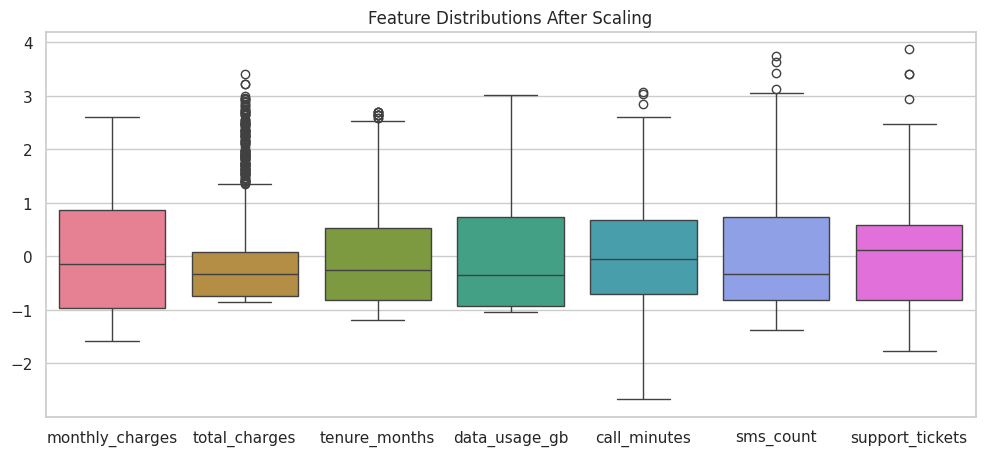

In [3]:
clustering_features = ['monthly_charges', 'total_charges', 'tenure_months', 'data_usage_gb', 'call_minutes', 'sms_count', 'support_tickets']
X = telecom_df[clustering_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

plt.figure(figsize=(12, 5))
sns.boxplot(data=X_scaled_df)
plt.title('Feature Distributions After Scaling')
plt.savefig('feature_scaling_comparison.png')
plt.show()

## 🤖 Task 3: KMeans Clustering Implementation

### ELI10
How many groups do we need? 2? 10? We use a 'Silhouette Score' which is like a teacher grading how well our groups are separated. The higher the grade, the better the number of groups.

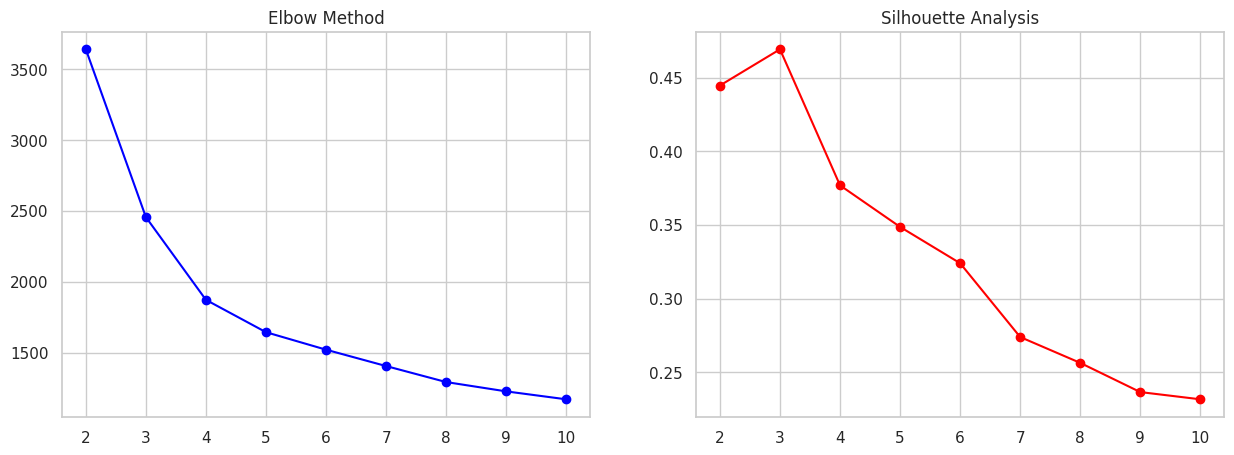

Selected optimal clusters: 3


In [4]:
def find_optimal_clusters(X, max_k=10):
    inertias, sil_scores = [], []
    k_range = range(2, max_k + 1)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, km.labels_))
    return k_range, inertias, sil_scores

k_range, inertias, sil_scores = find_optimal_clusters(X_scaled)
optimal_k = k_range[np.argmax(sil_scores)]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(k_range, inertias, 'bo-'); ax[0].set_title('Elbow Method')
ax[1].plot(k_range, sil_scores, 'ro-'); ax[1].set_title('Silhouette Analysis')
plt.savefig('kmeans_selection_metrics.png')
plt.show()

# Final Fit
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
telecom_df['cluster'] = kmeans.fit_predict(X_scaled)
print(f'Selected optimal clusters: {optimal_k}')

## 📉 Task 4: Principal Component Analysis (PCA)

### ELI10
We can't see in 7 dimensions! PCA is like taking a 3D object and looking at its shadow on a flat piece of paper. It squeezes our 7 numbers into 2 special ones so we can draw a map.

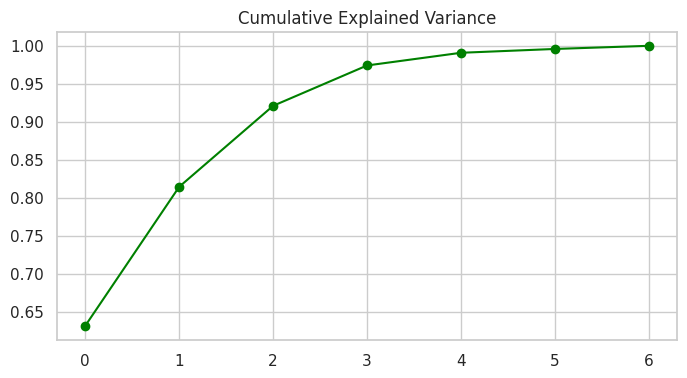

Total Variance Explained by 2 PCs: 81.44%


In [5]:
pca_full = PCA().fit(X_scaled)
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = telecom_df['cluster']

# Explained Variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), 'go-')
plt.title('Cumulative Explained Variance')
plt.savefig('pca_explained_variance.png')
plt.show()

print(f'Total Variance Explained by 2 PCs: {pca_2d.explained_variance_ratio_.sum():.2%}')

## 📊 Task 5: Visualizing Clusters in 2D Space

### ELI10
Now we finally see our clusters! Every dot is a customer, and the 'X' is the center of their group.

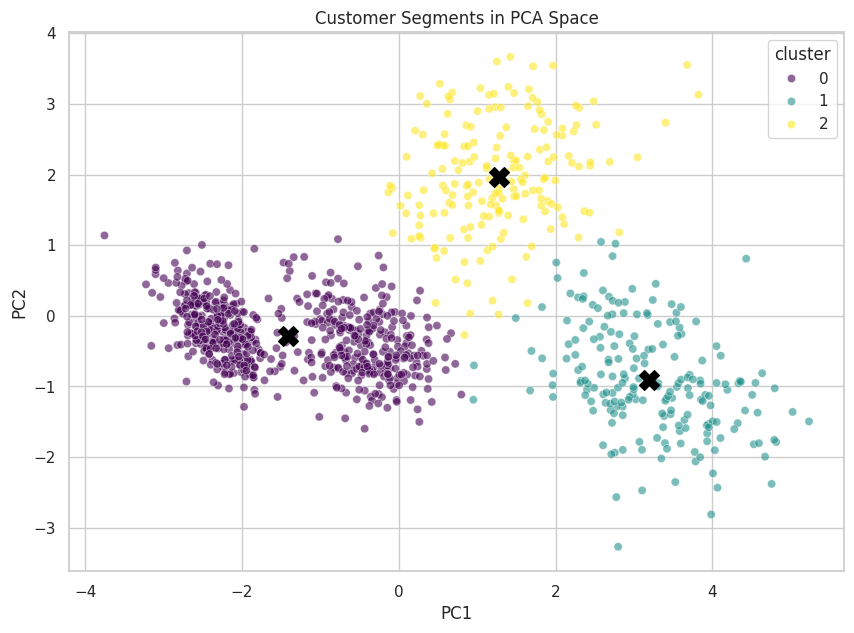

In [6]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='viridis', alpha=0.6)
centers_pca = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:,0], centers_pca[:,1], marker='X', s=200, color='black', label='Centroids')
plt.title('Customer Segments in PCA Space')
plt.savefig('customer_clusters_pca.png')
plt.show()

## ✅ Task 6 & 💾 Task 7: Validation and Reporting

### ELI10
We wrap up by checking our work and writing a summary report so we can tell the boss what we found.

Report and CSV generated successfully!


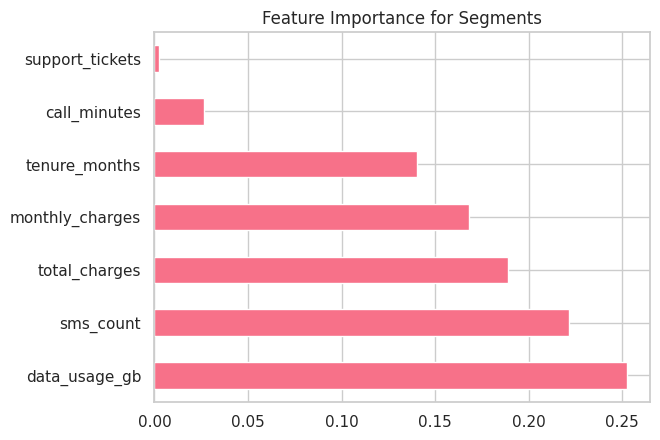

In [7]:
# Feature Importance using Random Forest as a proxy
rf = RandomForestClassifier(random_state=42).fit(X_scaled, telecom_df['cluster'])
importances = pd.Series(rf.feature_importances_, index=clustering_features).sort_values(ascending=False)

# Save Final Results
telecom_df.to_csv('telecom_clustering_results.csv', index=False)

with open('clustering_analysis_report.txt', 'w') as f:
    f.write(f'--- Clustering Lab Report ---\n')
    f.write(f'Optimal Clusters: {optimal_k}\n')
    f.write(f'Silhouette Score: {silhouette_score(X_scaled, telecom_df["cluster"]):.3f}\n')
    f.write(f'Top Discriminating Feature: {importances.index[0]}\n')

print('Report and CSV generated successfully!')
importances.plot(kind='barh', title='Feature Importance for Segments')
plt.show()

## 🏁 Conclusion
In this lab, you transformed raw behavioral data into actionable business segments. You used **KMeans** to find patterns and **PCA** to visualize them.

### 🛠 Troubleshooting
- **Overlap?** Try different scaling methods or removing outliers.
- **Low Variance?** Add more PCA components.
- **Slow run?** Use a smaller sample of `n_customers`.

## ✅ Verification Checklist
Check off the following items to ensure your analysis is complete:
- [x] **Dataset Created:** Realistic telecom data generated and saved to CSV.
- [x] **Exploration:** Visualized feature distributions and contract types.
- [x] **Scaling:** Standardized numeric features for fair distance calculation.
- [x] **Optimal K:** Evaluated Elbow and Silhouette metrics to find the best cluster count.
- [x] **Clustering:** Successfully grouped customers and analyzed group statistics.
- [x] **PCA:** Reduced data to 2D and verified the explained variance ratio.
- [x] **Visualization:** Plotted clusters in PCA space with identified centroids.
- [x] **Validation:** Computed Silhouette and Davies-Bouldin scores.
- [x] **Reporting:** Generated and saved the `clustering_analysis_report.txt`.

## 📚 Key Concepts & What You Learned
In this lab, you mastered the full unsupervised learning pipeline:

1.  **Unsupervised Grouping:** How to find patterns in data without pre-existing labels using **KMeans**.
2.  **Distance-Based Logic:** Why **Standardization** is critical for algorithms that calculate distances between points.
3.  **Dimensionality Reduction:** How **PCA** compresses high-dimensional data into visualizable components while retaining most of the information.
4.  **Cluster Validation:** Using the **Silhouette Score** to objectively measure how well-separated your groups are.
5.  **Business Translation:** How to map technical cluster metrics to real-world customer personas like "High-Value Loyalists" or "Budget Users".

## 🌍 Real-World Importance
These techniques are the backbone of modern data-driven decision making:

- **Marketing:** Customer Segmentation allows for personalized email campaigns and product recommendations.
- **Telecommunications:** Identifying "Churn Risk" groups by looking at tenure and support ticket patterns.
- **Finance:** Grouping transaction behaviors to detect outliers that might indicate credit card fraud.
- **E-commerce:** Understanding product affinity groups to improve cross-selling strategies.
- **Healthcare:** Segmenting patient data to identify common response patterns to specific treatments.